# Random Forest & Ensemble Experiments — Maximizing Fraud Recall

This notebook systematically tests multiple tree-based models and configurations,
applies F1-optimal and F2-optimal threshold tuning to each, and produces a final
comparison table to identify the best model for fraud recall.

**Experiments:**
1. Baseline Random Forest
2. Random Forest + `class_weight='balanced'`
3. SMOTE + Random Forest (multiple sampling ratios)
4. Calibrated Random Forest
5. Extra Trees Classifier
6. Balanced Random Forest (imblearn)

Each experiment reports **default threshold (0.5)**, **F1-optimal**, and **F2-optimal** results.

In [12]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    average_precision_score, recall_score, precision_score, f1_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

print('All imports OK')

All imports OK


## 1. Data Loading & Preprocessing

In [13]:
#download data from kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'mlg-ulb/creditcardfraud',
    'creditcard.csv'
)

print(f"Dataset shape: {df.shape}")
print(f"Fraud ratio: {df['Class'].mean():.4%}")

new_df = df.copy()
new_df['Amount'] = RobustScaler().fit_transform(new_df['Amount'].to_numpy().reshape(-1, 1))
new_df['Time']   = StandardScaler().fit_transform(new_df[['Time']])
new_df = new_df.sample(frac=1, random_state=42)

train, temp = train_test_split(new_df, test_size=0.2, stratify=new_df['Class'], random_state=42)
test,  val  = train_test_split(temp,   test_size=0.5, stratify=temp['Class'],   random_state=42)

x_train = train.drop(columns=['Class']); y_train = train['Class']
x_test  = test.drop(columns=['Class']);  y_test  = test['Class']
x_val   = val.drop(columns=['Class']);   y_val   = val['Class']

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")
print(f"Val fraud count: {y_val.sum()} / {len(y_val)}")

Dataset shape: (284807, 31)
Fraud ratio: 0.1727%
Train: (227845, 30), Val: (28481, 30), Test: (28481, 30)
Val fraud count: 49 / 28481


## 2. Shared Evaluation Helper

Sweeps all thresholds on the precision-recall curve and returns metrics
at the **default (0.5)**, **F1-optimal**, and **F2-optimal** operating points.

In [14]:
results = []

def evaluate(name, y_true, y_proba):
    """Evaluate a model at default, F1-optimal, and F2-optimal thresholds."""
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_true, y_proba)
    n = len(thr_arr)
    eps = 1e-9

    f1 = np.array([2*prec_arr[j+1]*rec_arr[j+1] / (prec_arr[j+1]+rec_arr[j+1]+eps) for j in range(n)])
    f2 = np.array([5*prec_arr[j+1]*rec_arr[j+1] / (4*prec_arr[j+1]+rec_arr[j+1]+eps) for j in range(n)])

    pr_auc = average_precision_score(y_true, y_proba)

    # Default threshold = 0.5
    pred_def = (y_proba >= 0.5).astype(int)
    results.append({
        'Experiment': name, 'Threshold': 'default (0.5)',
        'Precision (fraud)': precision_score(y_true, pred_def),
        'Recall (fraud)': recall_score(y_true, pred_def),
        'Recall (legit)': recall_score(y_true, pred_def, pos_label=0),
        'F1 (fraud)': f1_score(y_true, pred_def),
        'PR-AUC': pr_auc
    })

    # F1-optimal
    j1 = np.argmax(f1)
    pred_f1 = (y_proba >= thr_arr[j1]).astype(int)
    results.append({
        'Experiment': name, 'Threshold': f'F1-opt ({thr_arr[j1]:.4f})',
        'Precision (fraud)': precision_score(y_true, pred_f1),
        'Recall (fraud)': recall_score(y_true, pred_f1),
        'Recall (legit)': recall_score(y_true, pred_f1, pos_label=0),
        'F1 (fraud)': f1_score(y_true, pred_f1),
        'PR-AUC': pr_auc
    })

    # F2-optimal (favors recall)
    j2 = np.argmax(f2)
    pred_f2 = (y_proba >= thr_arr[j2]).astype(int)
    results.append({
        'Experiment': name, 'Threshold': f'F2-opt ({thr_arr[j2]:.4f})',
        'Precision (fraud)': precision_score(y_true, pred_f2),
        'Recall (fraud)': recall_score(y_true, pred_f2),
        'Recall (legit)': recall_score(y_true, pred_f2, pos_label=0),
        'F1 (fraud)': f1_score(y_true, pred_f2),
        'PR-AUC': pr_auc
    })

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"\n--- Default threshold (0.5) ---")
    print(classification_report(y_true, pred_def, target_names=['Legit (0)', 'Fraud (1)']))
    print(f"--- F1-optimal threshold ({thr_arr[j1]:.4f}) ---")
    print(classification_report(y_true, pred_f1, target_names=['Legit (0)', 'Fraud (1)']))
    print(f"--- F2-optimal threshold ({thr_arr[j2]:.4f}) ---")
    print(classification_report(y_true, pred_f2, target_names=['Legit (0)', 'Fraud (1)']))

    return pred_f2

print('evaluate() helper ready')

evaluate() helper ready


## 3. Experiment 1 — Baseline Random Forest

In [15]:
rf_base = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1
)
rf_base.fit(x_train, y_train)
proba = rf_base.predict_proba(x_val)[:, 1]
evaluate('1. Baseline RF', y_val, proba)


1. Baseline RF
PR-AUC: 0.8364

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.93      0.76      0.83        49

    accuracy                           1.00     28481
   macro avg       0.96      0.88      0.92     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.2933) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.1467) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.84      0.86      0.85        49

    accuracy                           1.0

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 4. Experiment 2 — RF + class_weight='balanced'

In [16]:
rf_bal = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_bal.fit(x_train, y_train)
proba = rf_bal.predict_proba(x_val)[:, 1]
evaluate('2. RF balanced', y_val, proba)


2. RF balanced
PR-AUC: 0.8237

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.92      0.71      0.80        49

    accuracy                           1.00     28481
   macro avg       0.96      0.86      0.90     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.2067) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.82      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.1533) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.85      0.84      0.85        49

    accuracy                           1.0

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 5. Experiment 3 — SMOTE + RF (multiple configs)

Tests several SMOTE sampling ratios with and without `class_weight='balanced'`.

In [17]:
smote_configs = [
    {'sampling_strategy': 0.2, 'k_neighbors': 5, 'class_weight': None,        'label': 'SMOTE 0.2'},
    {'sampling_strategy': 0.3, 'k_neighbors': 5, 'class_weight': None,        'label': 'SMOTE 0.3'},
    {'sampling_strategy': 0.4, 'k_neighbors': 5, 'class_weight': None,        'label': 'SMOTE 0.4'},
    {'sampling_strategy': 0.5, 'k_neighbors': 5, 'class_weight': None,        'label': 'SMOTE 0.5'},
    {'sampling_strategy': 0.3, 'k_neighbors': 5, 'class_weight': 'balanced',  'label': 'SMOTE 0.3 + balanced'},
    {'sampling_strategy': 0.5, 'k_neighbors': 5, 'class_weight': 'balanced',  'label': 'SMOTE 0.5 + balanced'},
]

for cfg in smote_configs:
    pipe = ImbPipeline([
        ('smote', SMOTE(
            sampling_strategy=cfg['sampling_strategy'],
            k_neighbors=cfg['k_neighbors'],
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            class_weight=cfg['class_weight'],
            random_state=42, n_jobs=-1
        ))
    ])
    pipe.fit(x_train, y_train)
    proba = pipe.predict_proba(x_val)[:, 1]
    evaluate(f'3. {cfg["label"]}', y_val, proba)


3. SMOTE 0.2
PR-AUC: 0.8288

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.82      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.5848) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.82      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.91      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.4585) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.85      0.84      0.85        49

    accuracy                           1.00 

## 6. Experiment 4 — Calibrated Random Forest

Probability calibration (sigmoid) can shift the probability distribution
and improve threshold-tuned recall.

In [18]:
rf_for_cal = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)

cal_rf = CalibratedClassifierCV(rf_for_cal, method='sigmoid', cv=5)
cal_rf.fit(x_train, y_train)

proba = cal_rf.predict_proba(x_val)[:, 1]
evaluate('4. Calibrated RF (balanced)', y_val, proba)


4. Calibrated RF (balanced)
PR-AUC: 0.8189

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.92      0.71      0.80        49

    accuracy                           1.00     28481
   macro avg       0.96      0.86      0.90     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.0081) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.87      0.84      0.85        49

    accuracy                           1.00     28481
   macro avg       0.94      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.0081) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.87      0.84      0.85        49

    accuracy                 

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 7. Experiment 5 — Extra Trees Classifier

ExtraTrees uses random splits instead of best splits, which can
reduce variance and sometimes improve minority-class recall.

In [19]:
et = ExtraTreesClassifier(
    n_estimators=300, class_weight='balanced',
    random_state=42, n_jobs=-1
)
et.fit(x_train, y_train)
proba = et.predict_proba(x_val)[:, 1]
evaluate('5. ExtraTrees (balanced)', y_val, proba)


5. ExtraTrees (balanced)
PR-AUC: 0.8374

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.95      0.76      0.84        49

    accuracy                           1.00     28481
   macro avg       0.97      0.88      0.92     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.2433) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.84      0.86        49

    accuracy                           1.00     28481
   macro avg       0.95      0.92      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.2433) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.84      0.86        49

    accuracy                    

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 8. Experiment 6 — Balanced Random Forest (imblearn)

Balanced RF under-samples the majority class in each bootstrap sample,
giving each tree a balanced view of fraud vs. non-fraud.

In [20]:
brf = BalancedRandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1
)
brf.fit(x_train, y_train)
proba = brf.predict_proba(x_val)[:, 1]
evaluate('6. BalancedRF (imblearn)', y_val, proba)


6. BalancedRF (imblearn)
PR-AUC: 0.7919

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.99      1.00     28432
   Fraud (1)       0.14      0.86      0.23        49

    accuracy                           0.99     28481
   macro avg       0.57      0.92      0.61     28481
weighted avg       1.00      0.99      0.99     28481

--- F1-optimal threshold (0.8667) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.88      0.86      0.87        49

    accuracy                           1.00     28481
   macro avg       0.94      0.93      0.93     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.8667) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.88      0.86      0.87        49

    accuracy                    

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 9. Experiment 7 — SMOTE + Extra Trees

In [21]:
pipe_et = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=0.3, k_neighbors=5, random_state=42)),
    ('et', ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])
pipe_et.fit(x_train, y_train)
proba = pipe_et.predict_proba(x_val)[:, 1]
evaluate('7. SMOTE 0.3 + ExtraTrees', y_val, proba)


7. SMOTE 0.3 + ExtraTrees
PR-AUC: 0.8375

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.91      0.80      0.85        49

    accuracy                           1.00     28481
   macro avg       0.95      0.90      0.92     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.4633) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.80      0.84        49

    accuracy                           1.00     28481
   macro avg       0.94      0.90      0.92     28481
weighted avg       1.00      1.00      1.00     28481

--- F2-optimal threshold (0.2400) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.80      0.84      0.82        49

    accuracy                   

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 10. Experiment 8 — RF + SMOTE + Hyperparameter Search

Randomized search over SMOTE ratios, RF depth, and leaf params,
scoring by `recall` to directly optimize for fraud detection.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

pipe_search = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'smote__sampling_strategy': [0.2, 0.3, 0.4, 0.5],
    'smote__k_neighbors': [3, 5, 7],
    'rf__n_estimators': [200, 300, 500],
    'rf__max_depth': [6, 8, 10, None],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': [None, 'balanced'],
}

search = RandomizedSearchCV(
    pipe_search, param_dist,
    n_iter=30, scoring='recall', cv=3,
    random_state=42, n_jobs=-1, verbose=1
)
search.fit(x_train, y_train)

print(f"\nBest CV recall: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

proba = search.best_estimator_.predict_proba(x_val)[:, 1]
evaluate('8. Tuned SMOTE+RF (recall search)', y_val, proba)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best CV recall: 0.8707
Best params: {'smote__sampling_strategy': 0.3, 'smote__k_neighbors': 5, 'rf__n_estimators': 300, 'rf__min_samples_leaf': 2, 'rf__max_depth': 6, 'rf__class_weight': 'balanced'}

8. Tuned SMOTE+RF (recall search)
PR-AUC: 0.6845

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.27      0.86      0.41        49

    accuracy                           1.00     28481
   macro avg       0.63      0.93      0.70     28481
weighted avg       1.00      1.00      1.00     28481

--- F1-optimal threshold (0.8120) ---
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     28432
   Fraud (1)       0.89      0.80      0.84        49

    accuracy                           1.00     28481
   macro avg       0.94      0.90      0.92     28481
weighted avg       

array([0, 0, 0, ..., 0, 0, 0], shape=(28481,))

## 11. Results Summary

All experiments compared side-by-side, sorted by recall (F2-optimal threshold).

In [23]:
results_df = pd.DataFrame(results)
for col in ['Precision (fraud)', 'Recall (fraud)', 'Recall (legit)', 'F1 (fraud)', 'PR-AUC']:
    results_df[col] = results_df[col].round(4)

print('=== ALL RESULTS ===')
print(results_df.to_string(index=False))

print('\n\n=== F2-OPTIMAL RESULTS ONLY (sorted by Fraud Recall) ===')
f2_df = results_df[results_df['Threshold'].str.startswith('F2')].sort_values('Recall (fraud)', ascending=False)
print(f2_df.to_string(index=False))

best_row = f2_df.iloc[0]
print(f"\n*** BEST MODEL FOR RECALL: {best_row['Experiment']}")
print(f"    Fraud Recall={best_row['Recall (fraud)']:.4f}  Legit Recall={best_row['Recall (legit)']:.4f}  Precision={best_row['Precision (fraud)']:.4f}  F1={best_row['F1 (fraud)']:.4f}  PR-AUC={best_row['PR-AUC']:.4f}")

=== ALL RESULTS ===
                       Experiment       Threshold  Precision (fraud)  Recall (fraud)  Recall (legit)  F1 (fraud)  PR-AUC
                   1. Baseline RF   default (0.5)             0.9250          0.7551          0.9999      0.8315  0.8364
                   1. Baseline RF F1-opt (0.2933)             0.8913          0.8367          0.9998      0.8632  0.8364
                   1. Baseline RF F2-opt (0.1467)             0.8400          0.8571          0.9997      0.8485  0.8364
                   2. RF balanced   default (0.5)             0.9211          0.7143          0.9999      0.8046  0.8237
                   2. RF balanced F1-opt (0.2067)             0.8889          0.8163          0.9998      0.8511  0.8237
                   2. RF balanced F2-opt (0.1533)             0.8542          0.8367          0.9998      0.8454  0.8237
                     3. SMOTE 0.2   default (0.5)             0.8889          0.8163          0.9998      0.8511  0.8288
            

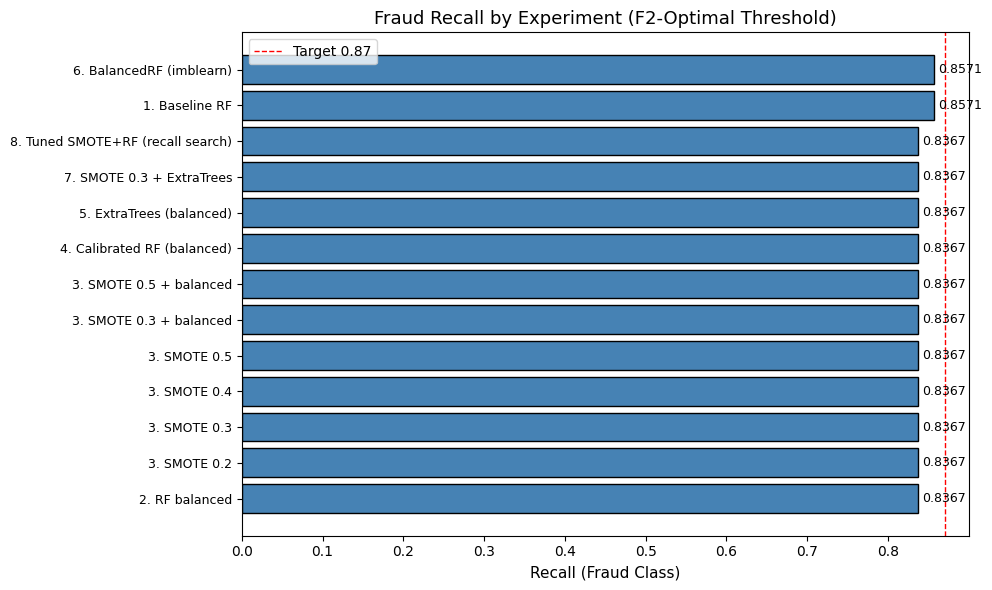

In [24]:
import matplotlib.pyplot as plt

f2_df_sorted = f2_df.sort_values('Recall (fraud)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(f2_df_sorted))
bars = ax.barh(y_pos, f2_df_sorted['Recall (fraud)'], color='steelblue', edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(f2_df_sorted['Experiment'], fontsize=9)
ax.set_xlabel('Recall (Fraud Class)', fontsize=11)
ax.set_title('Fraud Recall by Experiment (F2-Optimal Threshold)', fontsize=13)
ax.axvline(x=0.87, color='red', linestyle='--', linewidth=1, label='Target 0.87')
ax.legend()

for bar, val in zip(bars, f2_df_sorted['Recall (fraud)']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Feature Selection — Top 15 and Top 12 Features

Reducing the feature set can remove noisy dimensions and sometimes improve recall.
We use the baseline RF's feature importances to rank all 30 features, then re-run
experiments with only the top 15 and top 12.

In [ ]:
importances = rf_base.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
all_features = x_train.columns

top15 = all_features[sorted_idx[:15]]
top12 = all_features[sorted_idx[:12]]

print("Top 15 features:", list(top15))
print("\nTop 12 features:", list(top12))

x_train_15 = x_train[top15]; x_val_15 = x_val[top15]; x_test_15 = x_test[top15]
x_train_12 = x_train[top12]; x_val_12 = x_val[top12]; x_test_12 = x_test[top12]

print(f"\nTop 15 shape: {x_train_15.shape}")
print(f"Top 12 shape: {x_train_12.shape}")

### Experiment 9 — RF on Top 15 Features

In [ ]:
configs_15 = [
    {'cw': None,       'smote': None, 'label': '9a. RF top-15'},
    {'cw': 'balanced', 'smote': None, 'label': '9b. RF top-15 balanced'},
    {'cw': None,       'smote': 0.3,  'label': '9c. SMOTE 0.3 + RF top-15'},
    {'cw': 'balanced', 'smote': 0.3,  'label': '9d. SMOTE 0.3 + RF top-15 balanced'},
    {'cw': 'balanced', 'smote': 0.5,  'label': '9e. SMOTE 0.5 + RF top-15 balanced'},
]

for cfg in configs_15:
    if cfg['smote'] is not None:
        model = ImbPipeline([
            ('smote', SMOTE(sampling_strategy=cfg['smote'], k_neighbors=5, random_state=42)),
            ('rf', RandomForestClassifier(
                n_estimators=300, max_depth=None, min_samples_leaf=2,
                class_weight=cfg['cw'], random_state=42, n_jobs=-1
            ))
        ])
    else:
        model = RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            class_weight=cfg['cw'], random_state=42, n_jobs=-1
        )
    model.fit(x_train_15, y_train)
    proba = model.predict_proba(x_val_15)[:, 1]
    evaluate(cfg['label'], y_val, proba)

### Experiment 10 — RF on Top 12 Features

In [ ]:
configs_12 = [
    {'cw': None,       'smote': None, 'label': '10a. RF top-12'},
    {'cw': 'balanced', 'smote': None, 'label': '10b. RF top-12 balanced'},
    {'cw': None,       'smote': 0.3,  'label': '10c. SMOTE 0.3 + RF top-12'},
    {'cw': 'balanced', 'smote': 0.3,  'label': '10d. SMOTE 0.3 + RF top-12 balanced'},
    {'cw': 'balanced', 'smote': 0.5,  'label': '10e. SMOTE 0.5 + RF top-12 balanced'},
]

for cfg in configs_12:
    if cfg['smote'] is not None:
        model = ImbPipeline([
            ('smote', SMOTE(sampling_strategy=cfg['smote'], k_neighbors=5, random_state=42)),
            ('rf', RandomForestClassifier(
                n_estimators=300, max_depth=None, min_samples_leaf=2,
                class_weight=cfg['cw'], random_state=42, n_jobs=-1
            ))
        ])
    else:
        model = RandomForestClassifier(
            n_estimators=300, max_depth=None, min_samples_leaf=2,
            class_weight=cfg['cw'], random_state=42, n_jobs=-1
        )
    model.fit(x_train_12, y_train)
    proba = model.predict_proba(x_val_12)[:, 1]
    evaluate(cfg['label'], y_val, proba)

### Updated Results Summary (including top-15 and top-12 feature experiments)

In [ ]:
results_df = pd.DataFrame(results)
for col in ['Precision (fraud)', 'Recall (fraud)', 'Recall (legit)', 'F1 (fraud)', 'PR-AUC']:
    results_df[col] = results_df[col].round(4)

print('=== F2-OPTIMAL RESULTS — ALL EXPERIMENTS (sorted by Fraud Recall) ===\n')
f2_df = results_df[results_df['Threshold'].str.startswith('F2')].sort_values('Recall (fraud)', ascending=False)
print(f2_df.to_string(index=False))

best_row = f2_df.iloc[0]
print(f"\n*** BEST MODEL FOR RECALL: {best_row['Experiment']}")
print(f"    Fraud Recall={best_row['Recall (fraud)']:.4f}  Legit Recall={best_row['Recall (legit)']:.4f}  Precision={best_row['Precision (fraud)']:.4f}  F1={best_row['F1 (fraud)']:.4f}  PR-AUC={best_row['PR-AUC']:.4f}")

In [ ]:
import matplotlib.pyplot as plt

f2_sorted = f2_df.sort_values('Recall (fraud)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(f2_sorted))
colors = ['#2ecc71' if '12' in exp else '#3498db' if '15' in exp else '#95a5a6'
          for exp in f2_sorted['Experiment']]
bars = ax.barh(y_pos, f2_sorted['Recall (fraud)'], color=colors, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(f2_sorted['Experiment'], fontsize=8)
ax.set_xlabel('Recall (Fraud Class)', fontsize=11)
ax.set_title('Fraud Recall by Experiment (F2-Optimal Threshold)', fontsize=13)
ax.axvline(x=0.87, color='red', linestyle='--', linewidth=1, label='Target 0.87')

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#95a5a6', edgecolor='black', label='All 30 features'),
    Patch(facecolor='#3498db', edgecolor='black', label='Top 15 features'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Top 12 features'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Target 0.87'),
]
ax.legend(handles=legend_handles, loc='lower right')

for bar, val in zip(bars, f2_sorted['Recall (fraud)']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()